Forecasting & Reconstructing the Lorenz-63 Attractor (LorenzConstLinQuadraticNVARtimedelay-RK23.py)

training nrmse: 9.977583820491865e-05
test nrmse: 0.0007782334034830599


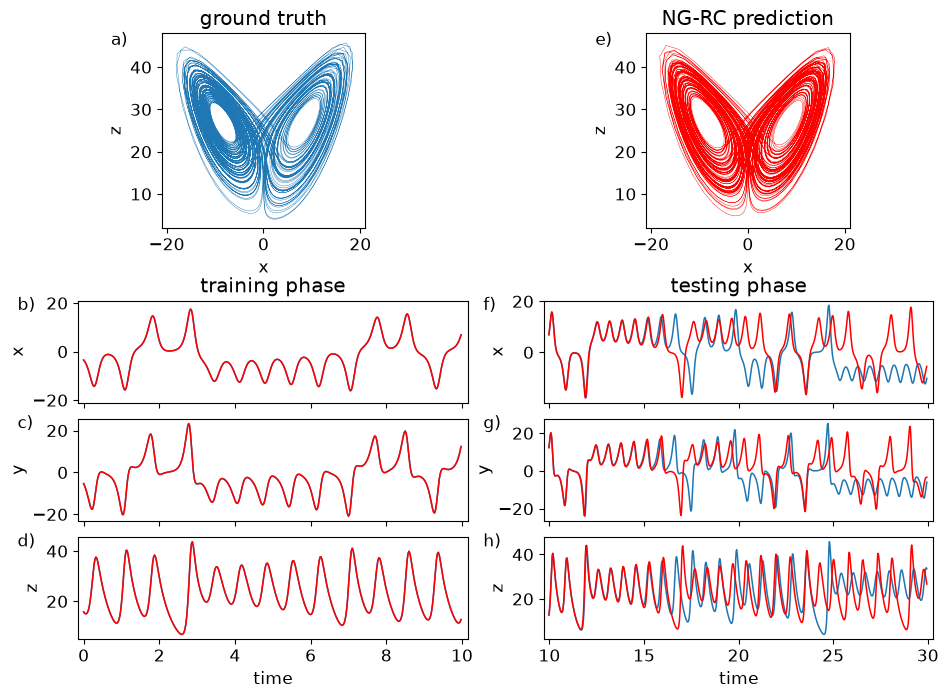

In [1]:
# -*- coding: utf-8 -*-
"""
Created on Sat Feb 20 13:17:10 2021

NVAR with time delays for Lorenz forecasting.  Don't be efficient for now.

@author: Dan
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

##
## Parameters
##

# time step
dt=0.025
# units of time to warm up NVAR. need to have warmup_pts >= 1
warmup = 5.
# units of time to train for
traintime = 10.
# units of time to test for
testtime=120.
# total time to run for
maxtime = warmup+traintime+testtime
# how much of testtime to plot
plottime=20.
# Lyapunov time of the Lorenz system
lyaptime=1.104

# discrete-time versions of the times defined above
warmup_pts=round(warmup/dt)
traintime_pts=round(traintime/dt)
warmtrain_pts=warmup_pts+traintime_pts
testtime_pts=round(testtime/dt)
maxtime_pts=round(maxtime/dt)
plottime_pts=round(plottime/dt)
lyaptime_pts=round(lyaptime/dt)

# input dimension
d = 3
# number of time delay taps
k = 2
# size of linear part of feature vector
dlin = k*d
# size of nonlinear part of feature vector
dnonlin = int(dlin*(dlin+1)/2)
# total size of feature vector: constant + linear + nonlinear
dtot = 1 + dlin + dnonlin

# ridge parameter for regression
ridge_param = 2.5e-6

# t values for whole evaluation time
# (need maxtime_pts + 1 to ensure a step of dt)
t_eval=np.linspace(0,maxtime,maxtime_pts+1)

##
## Lorenz '63
##

sigma = 10
beta = 8 / 3
rho = 28

def lorenz(t, y):
  
  dy0 = sigma * (y[1] - y[0])
  dy1 = y[0] * (rho - y[2]) - y[1]
  dy2 = y[0] * y[1] - beta * y[2]
  
  # since lorenz is 3-dimensional, dy/dt should be an array of 3 values
  return [dy0, dy1, dy2]

# I integrated out to t=50 to find points on the attractor, then use these as the initial conditions

lorenz_soln = solve_ivp(lorenz, (0, maxtime), [17.67715816276679, 12.931379185960404, 43.91404334248268] , t_eval=t_eval, method='RK23')

# total variance of Lorenz solution
total_var=np.var(lorenz_soln.y[0:d,:])

##
## NVAR
##

# create an array to hold the linear part of the feature vector
x = np.zeros((dlin,maxtime_pts))

# fill in the linear part of the feature vector for all times
for delay in range(k):
    for j in range(delay,maxtime_pts):
        x[d*delay:d*(delay+1),j]=lorenz_soln.y[:,j-delay]

# create an array to hold the full feature vector for training time
# (use ones so the constant term is already 1)
out_train = np.ones((dtot,traintime_pts))

# copy over the linear part (shift over by one to account for constant)
out_train[1:dlin+1,:]=x[:,warmup_pts-1:warmtrain_pts-1]

# fill in the non-linear part
cnt=0
for row in range(dlin):
    for column in range(row,dlin):
        # shift by one for constant
        out_train[dlin+1+cnt]=x[row,warmup_pts-1:warmtrain_pts-1]*x[column,warmup_pts-1:warmtrain_pts-1]
        cnt += 1

# ridge regression: train W_out to map out_train to Lorenz[t] - Lorenz[t - 1]
W_out = (x[0:d,warmup_pts:warmtrain_pts]-x[0:d,warmup_pts-1:warmtrain_pts-1]) @ out_train[:,:].T @ np.linalg.pinv(out_train[:,:] @ out_train[:,:].T + ridge_param*np.identity(dtot))

# apply W_out to the training feature vector to get the training output
x_predict = x[0:d,warmup_pts-1:warmtrain_pts-1] + W_out @ out_train[:,0:traintime_pts]

# calculate NRMSE between true Lorenz and training output
rms = np.sqrt(np.mean((x[0:d,warmup_pts:warmtrain_pts]-x_predict[:,:])**2)/total_var)
print('training nrmse: '+str(rms))

# create a place to store feature vectors for prediction
out_test = np.zeros(dtot)              # full feature vector
x_test = np.zeros((dlin,testtime_pts)) # linear part

# copy over initial linear feature vector
x_test[:,0] = x[:,warmtrain_pts-1]

# do prediction
for j in range(testtime_pts-1):
    # copy linear part into whole feature vector
    out_test[1:dlin+1]=x_test[:,j] # shift by one for constant
    # fill in the non-linear part
    cnt=0
    for row in range(dlin):
        for column in range(row,dlin):
            # shift by one for constant
            out_test[dlin+1+cnt]=x_test[row,j]*x_test[column,j]
            cnt += 1
    # fill in the delay taps of the next state
    x_test[d:dlin,j+1]=x_test[0:(dlin-d),j]
    # do a prediction
    x_test[0:d,j+1] = x_test[0:d,j]+W_out @ out_test[:]

# calculate NRMSE between true Lorenz and prediction for one Lyapunov time
test_nrmse = np.sqrt(np.mean((x[0:d,warmtrain_pts-1:warmtrain_pts+lyaptime_pts-1]-x_test[0:d,0:lyaptime_pts])**2)/total_var)
print('test nrmse: '+str(test_nrmse))

##
## Plot
##

t_linewidth=1.1
a_linewidth=0.3
plt.rcParams.update({'font.size': 12})

fig1 = plt.figure()
fig1.set_figheight(8)
fig1.set_figwidth(12)

xlabel=[10,15,20,25,30]
h=120
w=100

# top left of grid is 0,0
axs1 = plt.subplot2grid(shape=(h,w), loc=(0, 9), colspan=22, rowspan=38) 
axs2 = plt.subplot2grid(shape=(h,w), loc=(52, 0), colspan=42, rowspan=20)
axs3 = plt.subplot2grid(shape=(h,w), loc=(75, 0), colspan=42, rowspan=20)
axs4 = plt.subplot2grid(shape=(h,w), loc=(98, 0), colspan=42, rowspan=20)
axs5 = plt.subplot2grid(shape=(h,w), loc=(0, 61), colspan=22, rowspan=38)
axs6 = plt.subplot2grid(shape=(h,w), loc=(52, 50),colspan=42, rowspan=20)
axs7 = plt.subplot2grid(shape=(h,w), loc=(75, 50), colspan=42, rowspan=20)
axs8 = plt.subplot2grid(shape=(h,w), loc=(98, 50), colspan=42, rowspan=20)

# true Lorenz attractor
axs1.plot(x[0,warmtrain_pts:maxtime_pts],x[2,warmtrain_pts:maxtime_pts],linewidth=a_linewidth)
axs1.set_xlabel('x')
axs1.set_ylabel('z')
axs1.set_title('ground truth')
axs1.text(-.25,.92,'a)', ha='left', va='bottom',transform=axs1.transAxes)
axs1.axes.set_xbound(-21,21)
axs1.axes.set_ybound(2,48)

# training phase x
axs2.set_title('training phase') 
axs2.plot(t_eval[warmup_pts:warmtrain_pts]-warmup,x[0,warmup_pts:warmtrain_pts],linewidth=t_linewidth)
axs2.plot(t_eval[warmup_pts:warmtrain_pts]-warmup,x_predict[0,:],linewidth=t_linewidth, color='r')
axs2.set_ylabel('x')
axs2.text(-.155,0.87,'b)', ha='left', va='bottom',transform=axs2.transAxes)
axs2.axes.xaxis.set_ticklabels([])
axs2.axes.set_ybound(-21.,21.)
axs2.axes.set_xbound(-.15,10.15)

# training phase y
axs3.plot(t_eval[warmup_pts:warmtrain_pts]-warmup,x[1,warmup_pts:warmtrain_pts],linewidth=t_linewidth)
axs3.plot(t_eval[warmup_pts:warmtrain_pts]-warmup,x_predict[1,:],linewidth=t_linewidth,color='r')
axs3.set_ylabel('y')
axs3.text(-.155,0.87,'c)', ha='left', va='bottom',transform=axs3.transAxes)
axs3.axes.xaxis.set_ticklabels([])
axs3.axes.set_xbound(-.15,10.15)

# training phase z
axs4.plot(t_eval[warmup_pts:warmtrain_pts]-warmup,x[2,warmup_pts:warmtrain_pts],linewidth=t_linewidth)
axs4.plot(t_eval[warmup_pts:warmtrain_pts]-warmup,x_predict[2,:],linewidth=t_linewidth,color='r')
axs4.set_ylabel('z')
axs4.text(-.155,0.87,'d)', ha='left', va='bottom',transform=axs4.transAxes)
axs4.set_xlabel('time')
axs4.axes.set_xbound(-.15,10.15)

# prediction attractor
axs5.plot(x_test[0,:],x_test[2,:],linewidth=a_linewidth,color='r')
axs5.set_xlabel('x')
axs5.set_ylabel('z')
axs5.set_title('NG-RC prediction')
axs5.text(-.25,0.92,'e)', ha='left', va='bottom',transform=axs5.transAxes)
axs5.axes.set_xbound(-21,21)
axs5.axes.set_ybound(2,48)

# testing phase x
axs6.set_title('testing phase')
axs6.set_xticks(xlabel)
axs6.plot(t_eval[warmtrain_pts-1:warmtrain_pts+plottime_pts-1]-warmup,x[0,warmtrain_pts-1:warmtrain_pts+plottime_pts-1],linewidth=t_linewidth)
axs6.plot(t_eval[warmtrain_pts-1:warmtrain_pts+plottime_pts-1]-warmup,x_test[0,0:plottime_pts],linewidth=t_linewidth,color='r')
axs6.set_ylabel('x')
axs6.text(-.155,0.87,'f)', ha='left', va='bottom',transform=axs6.transAxes)
axs6.axes.xaxis.set_ticklabels([])
axs6.axes.set_xbound(9.7,30.3)

# testing phase y
axs7.set_xticks(xlabel)
axs7.plot(t_eval[warmtrain_pts-1:warmtrain_pts+plottime_pts-1]-warmup,x[1,warmtrain_pts-1:warmtrain_pts+plottime_pts-1],linewidth=t_linewidth)
axs7.plot(t_eval[warmtrain_pts-1:warmtrain_pts+plottime_pts-1]-warmup,x_test[1,0:plottime_pts],linewidth=t_linewidth,color='r')
axs7.set_ylabel('y')
axs7.text(-.155,0.87,'g)', ha='left', va='bottom',transform=axs7.transAxes)
axs7.axes.xaxis.set_ticklabels([])
axs7.axes.set_xbound(9.7,30.3)

# testing phase z
axs8.set_xticks(xlabel)
axs8.plot(t_eval[warmtrain_pts-1:warmtrain_pts+plottime_pts-1]-warmup,x[2,warmtrain_pts-1:warmtrain_pts+plottime_pts-1],linewidth=t_linewidth)
axs8.plot(t_eval[warmtrain_pts-1:warmtrain_pts+plottime_pts-1]-warmup,x_test[2,0:plottime_pts],linewidth=t_linewidth,color='r')
axs8.set_ylabel('z')
axs8.text(-.155,0.87,'h)', ha='left', va='bottom',transform=axs8.transAxes)
axs8.set_xlabel('time')
axs8.axes.set_xbound(9.7,30.3)

plt.savefig('predict-lorenz.png')
plt.savefig('predict-lorenz.svg')
plt.savefig('predict-lorenz.eps')
plt.savefig('predict-lorenz.pdf')

Forecasting a Non-Polynomial Double-Scroll Circuit (DoubleScrollNVAR-RK23.py)


 ridge regression parameter: 0.001

mean, meanerr, train nrmse: 0.0011766251320087797 3.898173326517321e-05
mean, meanerr, test nrmse: 0.012943389886846022 0.007321476469778019

mean, meanerr, fp1 nL2 distance: 0.0021302355018348695 0.00035954419834709846
mean, meanerr, fp2 nL2 distance: 0.002130235501834666 0.0003595441983470585
mean, meanerr, fp0 nL2 distance: 0.0 0.0

mean, meanerr, fp1 [-1.67300715e-03 -9.62303344e-05 -1.31307991e-03] [2.87102201e-04 1.88041122e-05 2.16891413e-04]
mean, meanerr, fp2 [1.67300715e-03 9.62303344e-05 1.31307991e-03] [2.87102201e-04 1.88041122e-05 2.16891413e-04]
mean, meanerr, fp0 [0. 0. 0.] [0. 0. 0.]

nL2 distance to mean, meanerr, fp1 0.00212894153537342 0.0003603098025158491
nL2 distance to mean, meanerr, fp2 0.002128941535373214 0.00036030980251581005
nL2 distance to mean, meanerr, fp0 0.0 0.0


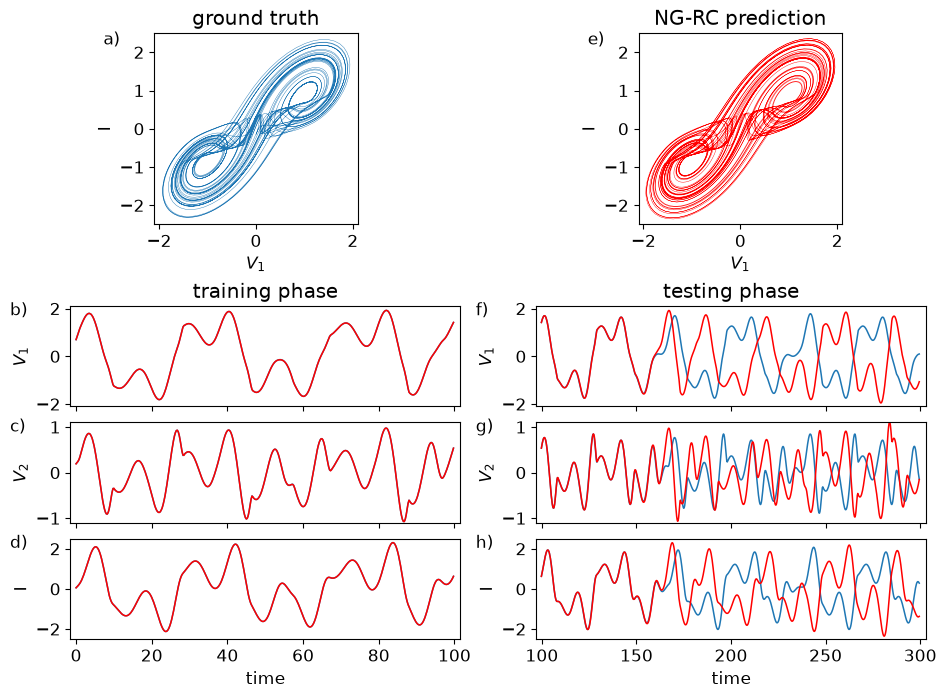

In [4]:
# -*- coding: utf-8 -*-
"""
Created on Sat Feb 20 13:17:10 2021

NVAR with time delays for double-scroll forecasting, NRMSE, and fixed points.
Don't be efficient for now.

Notes:  for a polynomial of size d raised to power n, there are
(d+n-1)!/(d-1)!n! terms.   For n=2, we have d(d+1)/2 terms. For n=3,
we have d(d+1)(d+2)/6 terms.

@author: Dan
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve

# do one trial of the NVAR, with the given warmup time
def do_nvar(warmup=1.):
  ##
  ## Parameters
  ##

  # time step
  dt=0.25
  # units of time to train for
  traintime=100.
  # units of time to test for
  testtime=800.
  # Lyapunov time of double-scroll system
  lyaptime=7.8125  # Henry Abarbanel finds Lyapunov exponent is 0.128
  # total time to run for
  maxtime = warmup+traintime+testtime

  # discrete-time versions of the times defined above
  warmup_pts=round(warmup/dt)
  traintime_pts=round(traintime/dt)
  warmtrain_pts=warmup_pts+traintime_pts
  testtime_pts=round(testtime/dt)
  maxtime_pts=round(maxtime/dt)
  lyaptime_pts=round(lyaptime/dt)

  # input dimension
  d = 3
  # number of time delay taps
  k = 2
  # size of the linear part of the feature vector
  dlin = k*d
  # size of the nonlinear part of feature vector
  dnonlin = int(dlin*(dlin+1)*(dlin+2)/6)
  # total size of feature vector: linear + nonlinear
  dtot = dlin + dnonlin

  # ridge parameter for regression
  ridge_param = 1.e-3

  # t values for whole evaluation time
  # (need maxtime_pts + 1 to ensure a step of dt)
  t_eval=np.linspace(0,maxtime,maxtime_pts+1)

  ##
  ## Double scroll
  ##

  r1 = 1.2
  r2 = 3.44
  r4 = 0.193
  alpha = 11.6
  ir = 2*2.25e-5 # the 2 is for the hyperbolic sine

  def doublescroll(t, y):
    # y[0] = V1, y[1] = V2, y[2] = I
    dV = y[0]-y[1] # V1-V2
    g = (dV/r2)+ir*np.sinh(alpha*dV)
    dy0 = (y[0]/r1)-g 
    dy1 = g-y[2]
    dy2 = y[1]-r4*y[2]

    return [dy0, dy1, dy2]

  # I integrated out to t=50 to find points on the attractor, then use these as the initial conditions

  doublescroll_soln = solve_ivp(doublescroll, (0, maxtime), [0.37926545,0.058339,-0.08167691] , t_eval=t_eval, method='RK23')

  # total variance of the double-scroll solution, corrected July 15, 2021 DJG
  total_var=np.var(doublescroll_soln.y[0,:])+np.var(doublescroll_soln.y[1,:])+np.var(doublescroll_soln.y[2,:])

  ##
  ## NVAR
  ##

  # create an array to hold the linear part of the feature vector
  x = np.zeros((dlin,maxtime_pts))

  # fill in the linear part of the feature vector for all times
  for delay in range(k):
      for j in range(delay,maxtime_pts):
          x[d*delay:d*(delay+1),j]=doublescroll_soln.y[:,j-delay]

  # create an array to hold the full feature vector for training time
  out_train = np.zeros((dtot,traintime_pts))  

  # copy over the linear part
  out_train[0:dlin,:]=x[:,warmup_pts-1:warmtrain_pts-1]

  # fill in the non-linear part
  cnt=0
  for row in range(dlin):
      for column in range(row,dlin):
          for span in range(column,dlin):
              out_train[dlin+cnt]=x[row,warmup_pts-1:warmtrain_pts-1]*x[column,warmup_pts-1:warmtrain_pts-1]*x[span,warmup_pts-1:warmtrain_pts-1]
              cnt += 1

  # ridge regression: train W_out to map out_train to DScroll[t] - DScroll[t - 1]
  W_out = (x[0:d,warmup_pts:warmtrain_pts]-x[0:d,warmup_pts-1:warmtrain_pts-1]) @ out_train[:,:].T @ np.linalg.pinv(out_train[:,:] @ out_train[:,:].T + ridge_param*np.identity(dtot))

  # apply W_out to the training feature vector to get the training output
  x_predict = x[0:d,warmup_pts-1:warmtrain_pts-1] + W_out @ out_train[:,0:traintime_pts]

  # calculate NRMSE between true double scroll and training output
  train_nrmse = np.sqrt(np.mean((x[0:d,warmup_pts:warmtrain_pts]-x_predict[:,:])**2)/total_var)

  # create a place to store feature vectors for prediction
  out_test = np.zeros(dtot)              # full feature vector
  x_test = np.zeros((dlin,testtime_pts)) # linear part

  # copy over initial linear feature vector
  x_test[:,0] = x[:,warmtrain_pts-1]

  # do prediction
  for j in range(testtime_pts-1):
      # copy linear part into whole feature vector
      out_test[0:dlin]=x_test[:,j]
      # fill in the non-linear part
      cnt=0
      for row in range(dlin):
          for column in range(row,dlin):
              for span in range(column,dlin):
                  out_test[dlin+cnt]=x_test[row,j]*x_test[column,j]*x_test[span,j]
                  cnt += 1
      # fill in the delay taps of the next state
      x_test[d:dlin,j+1]=x_test[0:(dlin-d),j]
      # do a prediction
      x_test[0:d,j+1] = x_test[0:d,j]+W_out @ out_test[:]

  # calculate NRMSE between true double scroll and prediction for one Lyapunov time
  nrmse = np.sqrt(np.mean((x[0:d,warmtrain_pts-1:warmtrain_pts+lyaptime_pts-1]-x_test[0:d,0:lyaptime_pts])**2)/total_var)

  # solve the transcendental equation that determines where the
  # true fixed points are located
  fp_slope = (r1 / r2) - (r4 / r2) - 1
  fp_sinhx = alpha * (1 - r4 / r1)
  fp_sinhy = r1 * ir
  fp_xs = np.linspace(-1.4, 1.4, 50)
  V1_fp = fsolve(lambda V1: fp_slope * V1 + fp_sinhy * np.sinh(fp_sinhx * V1), 1.05)

  # setup variabled for predicted and true fixed points
  t_fp0=np.zeros(d)
  t_fp1=np.zeros(d)
  t_fp2=np.zeros(d)

  V1_fp = np.asarray(V1_fp).item()
  # true fixed point 0 is 0
  # true fixed point 1 is at...
  t_fp1[0]=V1_fp
  t_fp1[1]=r4 * V1_fp / r1
  t_fp1[2]=V1_fp / r1
  # true fixed point 2 is at...
  t_fp2[0]=-t_fp1[0]
  t_fp2[1]=-t_fp1[1]
  t_fp2[2]=-t_fp1[2]

  # this function does a single step NVAR prediction for a trial fixed point
  # and returns the difference between the input and prediction
  # we can then solve func(p_fp) == 0 to find a fixed point p_fp
  def func(p_fp):
      # create a trial input feature vector
      out_vec=np.ones(dtot)
      # fill in the linear part
      for ii in range(k):
          # all past input is p_fp
          out_vec[ii*d:(ii+1)*d]=p_fp[0:d]
      # fill in the nonlinear part of the feature vector
      cnt=0
      for row in range(dlin):
          for column in range(row,dlin):
            for span in range(column,dlin):
              out_vec[dlin+cnt]=out_vec[row]*out_vec[column]*out_vec[span]
              cnt += 1
      return W_out @ out_vec

  # solve for the first fixed point and calculate distances
  p_fp1 = fsolve(func, t_fp1)
  n_fp1_diff=np.sqrt(np.sum((t_fp1-p_fp1)**2)/total_var)
  p_fp1_norm = (t_fp1 - p_fp1) / np.sqrt(total_var)

  # solve for second fixed point
  p_fp2 = fsolve(func, t_fp2)
  n_fp2_diff=np.sqrt(np.sum((t_fp2-p_fp2)**2)/total_var)
  p_fp2_norm = (t_fp2 - p_fp2) / np.sqrt(total_var)

  # solve for 0 fixed point
  p_fp0=fsolve(func, t_fp0)
  n_fp0_diff=np.sqrt(np.sum((t_fp0-p_fp0)**2)/total_var)
  p_fp0_norm = (t_fp0 - p_fp0) / np.sqrt(total_var)
  
  # return all our local variables we've defined
  return locals()

# plot the prediction, given the local variables from do_nvar
def do_plot(dt, x, warmtrain_pts, maxtime_pts, t_eval, warmup_pts, warmup, x_predict, x_test, **extra):
  # amount of time to plot prediction for
  plottime=200.
  plottime_pts=round(plottime/dt)

  t_linewidth=1.1
  a_linewidth=0.3
  plt.rcParams.update({'font.size': 12})

  fig1 = plt.figure()
  fig1.set_figheight(8)
  fig1.set_figwidth(12)

  xlabel=[100,150,200,250,300]
  sectionskip = 2
  h=120 + sectionskip
  w=100

  # top left of grid is 0,0
  axs1 = plt.subplot2grid(shape=(h,w), loc=(0, 9), colspan=22, rowspan=38) 
  axs2 = plt.subplot2grid(shape=(h,w), loc=(52+sectionskip, 0), colspan=42, rowspan=20)
  axs3 = plt.subplot2grid(shape=(h,w), loc=(75+sectionskip, 0), colspan=42, rowspan=20)
  axs4 = plt.subplot2grid(shape=(h,w), loc=(98+sectionskip, 0), colspan=42, rowspan=20)
  axs5 = plt.subplot2grid(shape=(h,w), loc=(0, 61), colspan=22, rowspan=38)
  axs6 = plt.subplot2grid(shape=(h,w), loc=(52+sectionskip, 50),colspan=42, rowspan=20)
  axs7 = plt.subplot2grid(shape=(h,w), loc=(75+sectionskip, 50), colspan=42, rowspan=20)
  axs8 = plt.subplot2grid(shape=(h,w), loc=(98+sectionskip, 50), colspan=42, rowspan=20)

  # true double scroll attractor
  axs1.plot(x[0,warmtrain_pts:maxtime_pts],x[2,warmtrain_pts:maxtime_pts],linewidth=a_linewidth)
  axs1.set_xlabel('$V_1$')
  axs1.set_ylabel('I')
  axs1.set_title('ground truth')
  axs1.text(-.25,.92,'a)', ha='left', va='bottom',transform=axs1.transAxes)
  axs1.axes.set_xbound(-2.1, 2.1)
  axs1.axes.set_ybound(-2.5, 2.5)

  # training phase V_1
  axs2.set_title('training phase')
  axs2.plot(t_eval[warmup_pts:warmtrain_pts]-warmup,x[0,warmup_pts:warmtrain_pts],linewidth=t_linewidth)
  axs2.plot(t_eval[warmup_pts:warmtrain_pts]-warmup,x_predict[0,:],linewidth=t_linewidth, color='r')
  axs2.set_ylabel('$V_1$')
  axs2.text(-.155,0.87,'b)', ha='left', va='bottom',transform=axs2.transAxes)
  axs2.axes.xaxis.set_ticklabels([])
  axs2.axes.set_xbound(-1.5,101.5)
  axs2.axes.set_ybound(-2.1, 2.1)

  # training phase V_2
  axs3.plot(t_eval[warmup_pts:warmtrain_pts]-warmup,x[1,warmup_pts:warmtrain_pts],linewidth=t_linewidth)
  axs3.plot(t_eval[warmup_pts:warmtrain_pts]-warmup,x_predict[1,:],linewidth=t_linewidth,color='r')
  axs3.set_ylabel('$V_2$')
  axs3.text(-.155,0.87,'c)', ha='left', va='bottom',transform=axs3.transAxes)
  axs3.axes.xaxis.set_ticklabels([])
  axs3.axes.set_xbound(-1.5,101.5)
  axs3.axes.set_ybound(-1.1, 1.1)

  # training phase I
  axs4.plot(t_eval[warmup_pts:warmtrain_pts]-warmup,x[2,warmup_pts:warmtrain_pts],linewidth=t_linewidth)
  axs4.plot(t_eval[warmup_pts:warmtrain_pts]-warmup,x_predict[2,:],linewidth=t_linewidth,color='r')
  axs4.set_ylabel('I')
  axs4.text(-.155,0.87,'d)', ha='left', va='bottom',transform=axs4.transAxes)
  axs4.set_xlabel('time')
  axs4.axes.set_xbound(-1.5,101.5)
  axs4.axes.set_ybound(-2.5, 2.5)

  # prediction attractor
  axs5.plot(x_test[0,:],x_test[2,:],linewidth=a_linewidth,color='r')
  axs5.set_xlabel('$V_1$')
  axs5.set_ylabel('I')
  axs5.set_title('NG-RC prediction')
  axs5.text(-.25,0.92,'e)', ha='left', va='bottom',transform=axs5.transAxes)
  axs5.axes.set_xbound(-2.1, 2.1)
  axs5.axes.set_ybound(-2.5, 2.5)

  # testing phase V_1
  axs6.set_title('testing phase')
  axs6.set_xticks(xlabel)
  axs6.plot(t_eval[warmtrain_pts-1:warmtrain_pts+plottime_pts-1]-warmup,x[0,warmtrain_pts-1:warmtrain_pts+plottime_pts-1],linewidth=t_linewidth)
  axs6.plot(t_eval[warmtrain_pts-1:warmtrain_pts+plottime_pts-1]-warmup,x_test[0,0:plottime_pts],linewidth=t_linewidth,color='r')
  axs6.set_ylabel('$V_1$')
  axs6.text(-.155,0.87,'f)', ha='left', va='bottom',transform=axs6.transAxes)
  axs6.axes.xaxis.set_ticklabels([])
  axs6.axes.set_xbound(97,303)
  axs6.axes.set_ybound(-2.1, 2.1)

  # testing phase V_2
  axs7.set_xticks(xlabel)
  axs7.plot(t_eval[warmtrain_pts-1:warmtrain_pts+plottime_pts-1]-warmup,x[1,warmtrain_pts-1:warmtrain_pts+plottime_pts-1],linewidth=t_linewidth)
  axs7.plot(t_eval[warmtrain_pts-1:warmtrain_pts+plottime_pts-1]-warmup,x_test[1,0:plottime_pts],linewidth=t_linewidth,color='r')
  axs7.set_ylabel('$V_2$')
  axs7.text(-.155,0.87,'g)', ha='left', va='bottom',transform=axs7.transAxes)
  axs7.axes.xaxis.set_ticklabels([])
  axs7.axes.set_xbound(97,303)
  axs7.axes.set_ybound(-1.1, 1.1)

  # testing phase I
  axs8.set_xticks(xlabel)
  axs8.plot(t_eval[warmtrain_pts-1:warmtrain_pts+plottime_pts-1]-warmup,x[2,warmtrain_pts-1:warmtrain_pts+plottime_pts-1],linewidth=t_linewidth)
  axs8.plot(t_eval[warmtrain_pts-1:warmtrain_pts+plottime_pts-1]-warmup,x_test[2,0:plottime_pts],linewidth=t_linewidth,color='r')
  axs8.set_ylabel('I')
  axs8.text(-.155,0.87,'h)', ha='left', va='bottom',transform=axs8.transAxes)
  axs8.set_xlabel('time')
  axs8.axes.set_xbound(97,303)
  axs8.axes.set_ybound(-2.5, 2.5)

# run one NVAR to plot the forecast
do_plot(**do_nvar())
plt.savefig('predict-dscroll.png')
plt.savefig('predict-dscroll.svg')
plt.savefig('predict-dscroll.eps')
plt.savefig('predict-dscroll.pdf')

# run many NVARs to calculate NRMSE and fixed points
# number of trials
npts=10
# storage for results
train_nrmse_v=np.zeros(npts)
test_nrmse_v=np.zeros(npts)
n_fp1_diff_v=np.zeros(npts)
n_fp2_diff_v=np.zeros(npts)
n_fp0_diff_v=np.zeros(npts)
p_fp1_norm_v=np.zeros((npts, 3))
p_fp2_norm_v=np.zeros((npts, 3))
p_fp0_norm_v=np.zeros((npts, 3))

# run all the trials and collect the results
for i in range(npts):
  r = do_nvar(warmup=1. + 100. * i)
  train_nrmse_v[i] = r['train_nrmse']
  test_nrmse_v[i] = r['nrmse']
  n_fp1_diff_v[i] = r['n_fp1_diff']
  n_fp2_diff_v[i] = r['n_fp2_diff']
  n_fp0_diff_v[i] = r['n_fp0_diff']
  p_fp1_norm_v[i] = r['p_fp1_norm']
  p_fp2_norm_v[i] = r['p_fp2_norm']
  p_fp0_norm_v[i] = r['p_fp0_norm']

#output summaries
print('\n ridge regression parameter: '+str(r['ridge_param'])+'\n')
print('mean, meanerr, train nrmse: '+str(np.mean(train_nrmse_v))+' '+str(np.std(train_nrmse_v)/np.sqrt(npts)))
print('mean, meanerr, test nrmse: '+str(np.mean(test_nrmse_v))+' '+str(np.std(test_nrmse_v)/np.sqrt(npts)))

# mean / err of (normalized L2 distance from true to predicted fixed point)
print()
print('mean, meanerr, fp1 nL2 distance: '+str(np.mean(n_fp1_diff_v))+' '+str(np.std(n_fp1_diff_v)/np.sqrt(npts)))
print('mean, meanerr, fp2 nL2 distance: '+str(np.mean(n_fp2_diff_v))+' '+str(np.std(n_fp2_diff_v)/np.sqrt(npts)))
print('mean, meanerr, fp0 nL2 distance: '+str(np.mean(n_fp0_diff_v))+' '+str(np.std(n_fp0_diff_v)/np.sqrt(npts)))

# mean / err of (normalized difference between true and predicted fixed point)
print()
print('mean, meanerr, fp1', np.mean(p_fp1_norm_v, axis=0), np.std(p_fp1_norm_v, axis=0) / np.sqrt(npts))
print('mean, meanerr, fp2', np.mean(p_fp2_norm_v, axis=0), np.std(p_fp2_norm_v, axis=0) / np.sqrt(npts))
print('mean, meanerr, fp0', np.mean(p_fp0_norm_v, axis=0), np.std(p_fp0_norm_v, axis=0) / np.sqrt(npts))

# mean / err of (normalized difference between true and predicted fixed point)
print()
print('nL2 distance to mean, meanerr, fp1', np.sqrt(np.sum(np.mean(p_fp1_norm_v, axis=0) ** 2)), np.sqrt(np.sum(np.var(p_fp1_norm_v, axis=0)) / npts))
print('nL2 distance to mean, meanerr, fp2', np.sqrt(np.sum(np.mean(p_fp2_norm_v, axis=0) ** 2)), np.sqrt(np.sum(np.var(p_fp2_norm_v, axis=0)) / npts))
print('nL2 distance to mean, meanerr, fp0', np.sqrt(np.sum(np.mean(p_fp0_norm_v, axis=0) ** 2)), np.sqrt(np.sum(np.var(p_fp0_norm_v, axis=0)) / npts))

Inferring Unseen Variables (LorenzPredictZQuadraticNVARtimedelay-RK23.py)

training rms: 0.08585204476621788
training nrms: 0.009889760825005329
testing rms: 0.07567723311793875
testing nrms: 0.008717669305054082


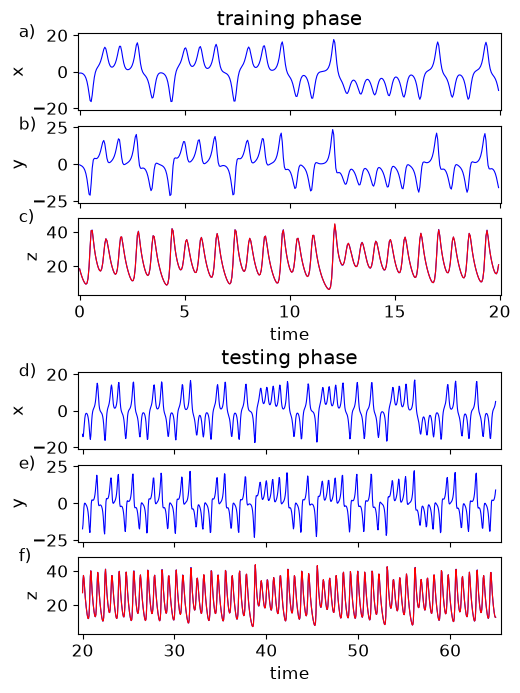

In [3]:
# -*- coding: utf-8 -*-
"""
Created on Sat Feb 20 13:17:10 2021

NVAR with time delays for Lorenz prediction.  Don't be efficient for now.

Measure x,y, predict z

@author: Dan
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

##
## Parameters
##

# time step
dt=0.05
# units of time to warm up NVAR, need to have warmup_pts >= 1
warmup = 5.
# units of time to train for
traintime = 20.
# units of time to test for
testtime=45.
# total time to run for
maxtime = warmup+traintime+testtime

# discrete-time versions of the times defined above
warmup_pts=round(warmup/dt)
traintime_pts=round(traintime/dt)
warmtrain_pts=warmup_pts+traintime_pts
testtime_pts=round(testtime/dt)
maxtime_pts=round(maxtime/dt)

# input dimension
d = 3
# number of time delay taps
k = 4
# number of time steps between taps. skip = 1 means take consecutive points
skip = 5
# size of linear part of feature vector (leave out z)
dlin = k*(d-1)
# size of nonlinear part of feature vector
dnonlin = int(dlin*(dlin+1)/2)
# total size of feature vector: linear + nonlinear
dtot = dlin + dnonlin

# ridge parameter for regression
ridge_param = .05

# make sure we have enough warmup time
assert k*skip <= warmup_pts

# t values for whole evaluation time
# (need maxtime_pts + 1 to ensure a step of dt)
t_eval=np.linspace(0,maxtime,maxtime_pts+1)

##
## Lorenz '63
##

sigma = 10
beta = 8 / 3
rho = 28

def lorenz(t, y):
  
  dy0 = sigma * (y[1] - y[0])
  dy1 = y[0] * (rho - y[2]) - y[1]
  dy2 = y[0] * y[1] - beta * y[2]
  
  # since lorenz is 3-dimensional, dy/dt should be an array of 3 values
  return [dy0, dy1, dy2]

# I integrated out to t=50 to find points on the attractor, then use these as the initial conditions

lorenz_soln = solve_ivp(lorenz, (0, maxtime), [17.67715816276679, 12.931379185960404, 43.91404334248268] , t_eval=t_eval, method='RK45')

# calculate standard deviation of z component
zstd = np.std(lorenz_soln.y[2,:])

##
## NVAR
##

# create an array to hold the linear part of the feature vector
x = np.zeros((dlin,maxtime_pts))

# create an array to hold the full feature vector for all time after warmup
# (use ones so the constant term is already 1)
out = np.ones((dtot+1,maxtime_pts-warmup_pts))

# fill in the linear part of the feature vector for all times
for delay in range(k):
    for j in range(delay,maxtime_pts):
        # only include x and y
        x[(d-1)*delay:(d-1)*(delay+1),j]=lorenz_soln.y[0:2,j-delay*skip]

# copy over the linear part (shift over by one to account for constant)
# unlike forecasting, we can do this all in one shot, and we don't need to
# shift times for one-step-ahead prediction
out[1:dlin+1,:]=x[:,warmup_pts:maxtime_pts]

# fill in the non-linear part
cnt=0
for row in range(dlin):
    for column in range(row,dlin):
        # shift by one for constant
        out[dlin+1+cnt,:]=x[row,warmup_pts:maxtime_pts]*x[column,warmup_pts:maxtime_pts]
        cnt += 1

# ridge regression: train W_out to map out to Lorenz z
W_out = lorenz_soln.y[2,warmup_pts:warmtrain_pts] @ out[:,0:traintime_pts].T @ np.linalg.pinv(out[:,0:traintime_pts] @ out[:,0:traintime_pts].T + ridge_param*np.identity(dtot+1))

# once we have W_out, we can predict the entire shot
# apply W_out to the feature vector to get the output
# this includes both training and testing phases
z_predict = W_out @ out[:,:]


# calculate NRMSE between true Lorenz z and training output
rms = np.sqrt(np.mean((lorenz_soln.y[2,warmup_pts:warmtrain_pts]-z_predict[0:traintime_pts])**2))
print('training rms: '+str(rms))
print('training nrms: '+str(rms/zstd))

# calculate NRMSE between true Lorenz z and prediction
rms = np.sqrt(np.mean((lorenz_soln.y[2,warmtrain_pts:maxtime_pts]-z_predict[traintime_pts:maxtime_pts-warmup_pts])**2))
print('testing rms: '+str(rms))
print('testing nrms: '+str(rms/zstd))

##
## Plot
##
    
t_linewidth=.8

fig1 = plt.figure()
fig1.set_figheight(8)
fig1.set_figwidth(12)

h=240
w=2

# top left of grid is 0,0
axs1 = plt.subplot2grid(shape=(h,w), loc=(0, 0), colspan=1, rowspan=30) 
axs2 = plt.subplot2grid(shape=(h,w), loc=(36, 0), colspan=1, rowspan=30)
axs3 = plt.subplot2grid(shape=(h,w), loc=(72, 0), colspan=1, rowspan=30)
axs4 = plt.subplot2grid(shape=(h,w), loc=(132, 0), colspan=1, rowspan=30)
axs5 = plt.subplot2grid(shape=(h,w), loc=(168, 0), colspan=1, rowspan=30)
axs6 = plt.subplot2grid(shape=(h,w), loc=(204, 0),colspan=1, rowspan=30)


# training phase x
axs1.set_title('training phase')
axs1.plot(t_eval[warmup_pts:warmtrain_pts]-warmup,x[0,warmup_pts:warmtrain_pts],color='b',linewidth=t_linewidth)
axs1.set_ylabel('x')
axs1.axes.xaxis.set_ticklabels([])
axs1.axes.set_xbound(-.08,traintime+.05)
axs1.axes.set_ybound(-21.,21.)
axs1.text(-.14,.9,'a)', ha='left', va='bottom',transform=axs1.transAxes)

# training phase y
axs2.plot(t_eval[warmup_pts:warmtrain_pts]-warmup,x[1,warmup_pts:warmtrain_pts],color='b',linewidth=t_linewidth)
axs2.set_ylabel('y')
axs2.axes.xaxis.set_ticklabels([])
axs2.axes.set_xbound(-.08,traintime+.05)
axs2.axes.set_ybound(-26.,26.)
axs2.text(-.14,.9,'b)', ha='left', va='bottom',transform=axs2.transAxes)

# training phase z
axs3.plot(t_eval[warmup_pts:warmtrain_pts]-warmup,lorenz_soln.y[2,warmup_pts:warmtrain_pts],color='b',linewidth=t_linewidth)
axs3.plot(t_eval[warmup_pts:warmtrain_pts]-warmup,z_predict[0:traintime_pts],color='r',linewidth=t_linewidth)
axs3.set_ylabel('z')
axs3.set_xlabel('time')
axs3.axes.set_xbound(-.08,traintime+.05)
axs3.axes.set_ybound(3.,48.)
axs3.text(-.14,.9,'c)', ha='left', va='bottom',transform=axs3.transAxes)

# testing phase x
axs4.set_title('testing phase')
axs4.plot(t_eval[warmtrain_pts:maxtime_pts]-warmup,x[0,warmtrain_pts:maxtime_pts],color='b',linewidth=t_linewidth)
axs4.set_ylabel('x')
axs4.axes.xaxis.set_ticklabels([])
axs4.axes.set_ybound(-21.,21.)
axs4.axes.set_xbound(traintime-.5,maxtime-warmup+.5)
axs4.text(-.14,.9,'d)', ha='left', va='bottom',transform=axs4.transAxes)

# testing phase y
axs5.plot(t_eval[warmtrain_pts:maxtime_pts]-warmup,x[1,warmtrain_pts:maxtime_pts],color='b',linewidth=t_linewidth)
axs5.set_ylabel('y')
axs5.axes.xaxis.set_ticklabels([])
axs5.axes.set_ybound(-26.,26.)
axs5.axes.set_xbound(traintime-.5,maxtime-warmup+.5)
axs5.text(-.14,.9,'e)', ha='left', va='bottom',transform=axs5.transAxes)

# testing phose z
axs6.plot(t_eval[warmtrain_pts:maxtime_pts]-warmup,lorenz_soln.y[2,warmtrain_pts:maxtime_pts],color='b',linewidth=t_linewidth)
axs6.plot(t_eval[warmtrain_pts:maxtime_pts]-warmup,z_predict[traintime_pts:maxtime_pts-warmup_pts],color='r',linewidth=t_linewidth)
axs6.set_ylabel('z')
axs6.set_xlabel('time')
axs6.axes.set_ybound(3.,48.)
axs6.axes.set_xbound(traintime-.5,maxtime-warmup+.5)
axs6.text(-.14,.9,'f)', ha='left', va='bottom',transform=axs6.transAxes)

plt.savefig('infer-lorenz.png')
plt.savefig('infer-lorenz.svg')
plt.savefig('infer-lorenz.eps')
plt.savefig('infer-lorenz.pdf')